# 01 — Data Quality

Loads the example experiment's market data through ``DataLoader``, which uses
the local cache and downloads missing ranges when the source is available.
It then runs the ``DataValidator`` and inspects coverage and basic statistics
before any research begins.

This step exists because a backtest is only as trustworthy as its input data: duplicates, gaps, and impossible OHLC bars must be
caught before they silently distort results.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from quantlab.config import ExperimentConfig
from quantlab.data.loader import DataLoader
from quantlab.data.base import price_matrix

config = ExperimentConfig.from_yaml("../configs/momentum_sp500.yaml")
config.experiment_name, config.symbols, config.start_date, config.end_date


('cross_sectional_momentum_etfs',
 ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD', 'VNQ'],
 datetime.date(2008, 1, 1),
 datetime.date(2025, 12, 31))

In [2]:
data, report = DataLoader().load(config)
print(report.summary())
for w in report.warnings:
    print(" -", w)


DataQualityReport(rows=36232/36232 clean/raw, duplicates=0, invalid_prices=0, missing_values=0, gaps=0, warnings=0)


## Coverage per symbol

In [3]:
data.groupby("symbol")["timestamp"].agg(["min", "max", "count"])


,min,max,count
symbol,,,
EEM,2008-01-02,2025-12-31,4529
EFA,2008-01-02,2025-12-31,4529
GLD,2008-01-02,2025-12-31,4529
IWM,2008-01-02,2025-12-31,4529
QQQ,2008-01-02,2025-12-31,4529
SPY,2008-01-02,2025-12-31,4529
TLT,2008-01-02,2025-12-31,4529
VNQ,2008-01-02,2025-12-31,4529


## Adjusted close price series

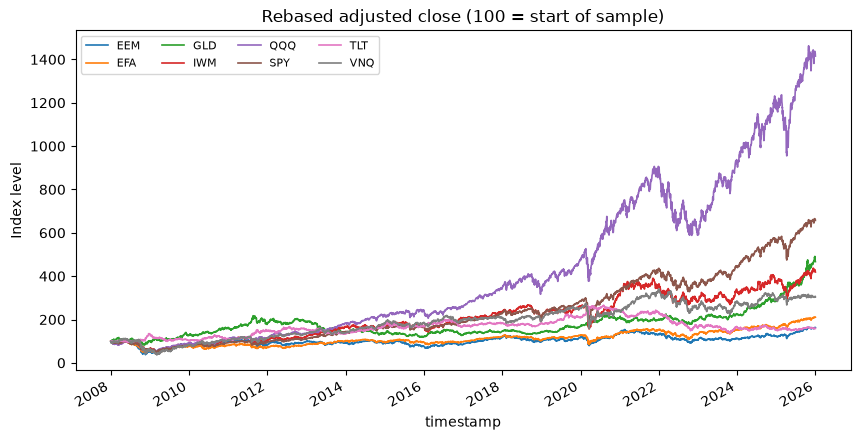

In [4]:
prices = price_matrix(data)
fig, ax = plt.subplots(figsize=(10, 5))
(prices / prices.iloc[0] * 100).plot(ax=ax, lw=1.2)
ax.set_title("Rebased adjusted close (100 = start of sample)")
ax.set_ylabel("Index level")
ax.legend(ncol=4, fontsize=8)
plt.show()


## Daily return summary statistics

In [5]:
returns = prices.pct_change(fill_method=None)
returns.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}")


,mean,std,min,max
EEM,0.0003,0.0175,-0.1617,0.2277
EFA,0.0003,0.0138,-0.1116,0.1589
GLD,0.0004,0.0110,-0.0878,0.1129
IWM,0.0004,0.0157,-0.1327,0.0915
QQQ,0.0007,0.0142,-0.1198,0.1216
SPY,0.0005,0.0126,-0.1094,0.1452
TLT,0.0001,0.0097,-0.0667,0.0752
VNQ,0.0004,0.0189,-0.1951,0.1701


## Takeaways

- No duplicate `(timestamp, symbol)` rows and no non-positive prices were
  found (or they would appear as warnings above).
- Coverage spans the full requested range for every symbol.
- Returns look like ordinary daily equity/ETF returns (no obviously broken
  bars). This is the baseline the rest of the research builds on.
